In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
train = pd.read_csv("../data/train-test.csv")
validation = pd.read_csv("../data/validation.csv")

In [4]:
train.shape

(48000, 14)

In [5]:
validation.shape

(12000, 13)

In [6]:
train.columns.tolist()

['load_id',
 'pickup',
 'delivery',
 'pickup_lat',
 'pickup_lon',
 'delivery_lat',
 'delivery_lon',
 'distance',
 'equipment',
 'weight',
 'date',
 'market_index',
 'quote_signal',
 'posted_rate']

In [7]:
train.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,1/1/2025,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,1/1/2025,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,1/1/2025,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,1/1/2025,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,1/1/2025,0.98480,2.56300,1380.28


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48000 entries, 0 to 47999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   load_id       48000 non-null  object 
 1   pickup        48000 non-null  object 
 2   delivery      48000 non-null  object 
 3   pickup_lat    48000 non-null  float64
 4   pickup_lon    48000 non-null  float64
 5   delivery_lat  48000 non-null  float64
 6   delivery_lon  48000 non-null  float64
 7   distance      48000 non-null  float64
 8   equipment     48000 non-null  object 
 9   weight        47700 non-null  float64
 10  date          48000 non-null  object 
 11  market_index  47626 non-null  float64
 12  quote_signal  48000 non-null  float64
 13  posted_rate   48000 non-null  float64
dtypes: float64(9), object(5)
memory usage: 5.1+ MB


In [9]:
set(train.columns) - set(validation.columns)

{'posted_rate'}

In [10]:
train.isnull().sum().sort_values(ascending=False)

market_index    374
weight          300
delivery          0
pickup_lat        0
load_id           0
pickup            0
delivery_lat      0
pickup_lon        0
distance          0
delivery_lon      0
equipment         0
date              0
quote_signal      0
posted_rate       0
dtype: int64

In [11]:
(train.isnull().mean()*100).sort_values(ascending=False)

market_index    0.779167
weight          0.625000
delivery        0.000000
pickup_lat      0.000000
load_id         0.000000
pickup          0.000000
delivery_lat    0.000000
pickup_lon      0.000000
distance        0.000000
delivery_lon    0.000000
equipment       0.000000
date            0.000000
quote_signal    0.000000
posted_rate     0.000000
dtype: float64

In [12]:
train.duplicated().sum()

np.int64(0)

In [13]:
duplicate_rows = train[train.duplicated()]
duplicate_rows.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate


In [14]:
train.describe()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
count,48000.000000,48000.000000,48000.000000,48000.000000,48000.000000,47700.000000,47626.000000,48000.000000,48000.000000
mean,35.647545,-90.928964,35.641175,-90.857310,1135.856654,31028.844004,1.083387,2.062468,2373.980682
std,4.315285,13.482431,4.317199,13.476589,728.564416,9391.440620,0.168091,0.291391,1486.493245
min,28.357650,-121.698490,28.357650,-121.698490,70.000000,-47500.000000,0.676390,0.692280,57.220000
25%,31.986910,-98.400590,31.986910,-98.400590,550.400000,25800.000000,0.949670,1.891030,1251.555000
50%,35.294790,-88.089150,35.294790,-87.528710,953.300000,31436.500000,1.055800,2.055750,2030.760000
75%,39.411040,-83.285060,39.411040,-83.285060,1645.525000,37018.000000,1.219590,2.221685,3330.750000
max,44.302960,-69.500000,44.302960,-69.500000,3439.800000,47500.000000,1.467780,3.610350,25533.000000


In [16]:
(train["weight"] < 0).sum()

np.int64(292)

In [17]:
(train["distance"] < 0).sum()

np.int64(0)

In [18]:
(train["posted_rate"] <= 0).sum()

np.int64(0)

In [19]:
(train["posted_rate"] <= 0).any()

np.False_

In [21]:
train["date"] = pd.to_datetime(train["date"])
(train["date"].min(), train["date"].max())

(Timestamp('2025-01-01 00:00:00'), Timestamp('2025-10-31 00:00:00'))

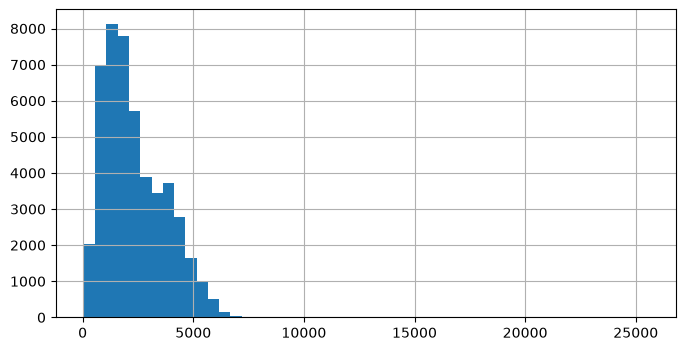

In [21]:
plt.figure(figsize=(8,4))

train["posted_rate"].hist(bins=50)

plt.show()

In [23]:
train["pickup"].nunique()

64

In [22]:
train["delivery"].nunique()

64

In [24]:
train["equipment"].value_counts()

equipment
Dry Van    27202
Reefer     12045
Flatbed     8753
Name: count, dtype: int64

In [25]:
numeric_cols = train.select_dtypes(include=np.number)
numeric_cols.corr()

,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate
pickup_lat,1.000000,0.559208,-0.008283,-0.006143,-0.077742,0.001898,-0.001735,-0.004181,-0.090873
pickup_lon,0.559208,1.000000,-0.008609,-0.012231,-0.273411,0.006603,0.001432,0.013659,-0.255058
delivery_lat,-0.008283,-0.008609,1.000000,0.557083,-0.080646,-0.004243,-0.002587,-0.002708,-0.091970
delivery_lon,-0.006143,-0.012231,0.557083,1.000000,-0.275657,-0.001144,-0.008487,0.011437,-0.257086
distance,-0.077742,-0.273411,-0.080646,-0.275657,1.000000,0.002544,-0.002181,-0.057244,0.908519
weight,0.001898,0.006603,-0.004243,-0.001144,0.002544,1.000000,-0.001331,0.008159,0.034840
market_index,-0.001735,0.001432,-0.002587,-0.008487,-0.002181,-0.001331,1.000000,-0.067827,0.034165
quote_signal,-0.004181,0.013659,-0.002708,0.011437,-0.057244,0.008159,-0.067827,1.000000,-0.039858
posted_rate,-0.090873,-0.255058,-0.091970,-0.257086,0.908519,0.034840,0.034165,-0.039858,1.000000


In [22]:
df = train
df.isnull().sum()

load_id           0
pickup            0
delivery          0
pickup_lat        0
pickup_lon        0
delivery_lat      0
delivery_lon      0
distance          0
equipment         0
weight          300
date              0
market_index    374
quote_signal      0
posted_rate       0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

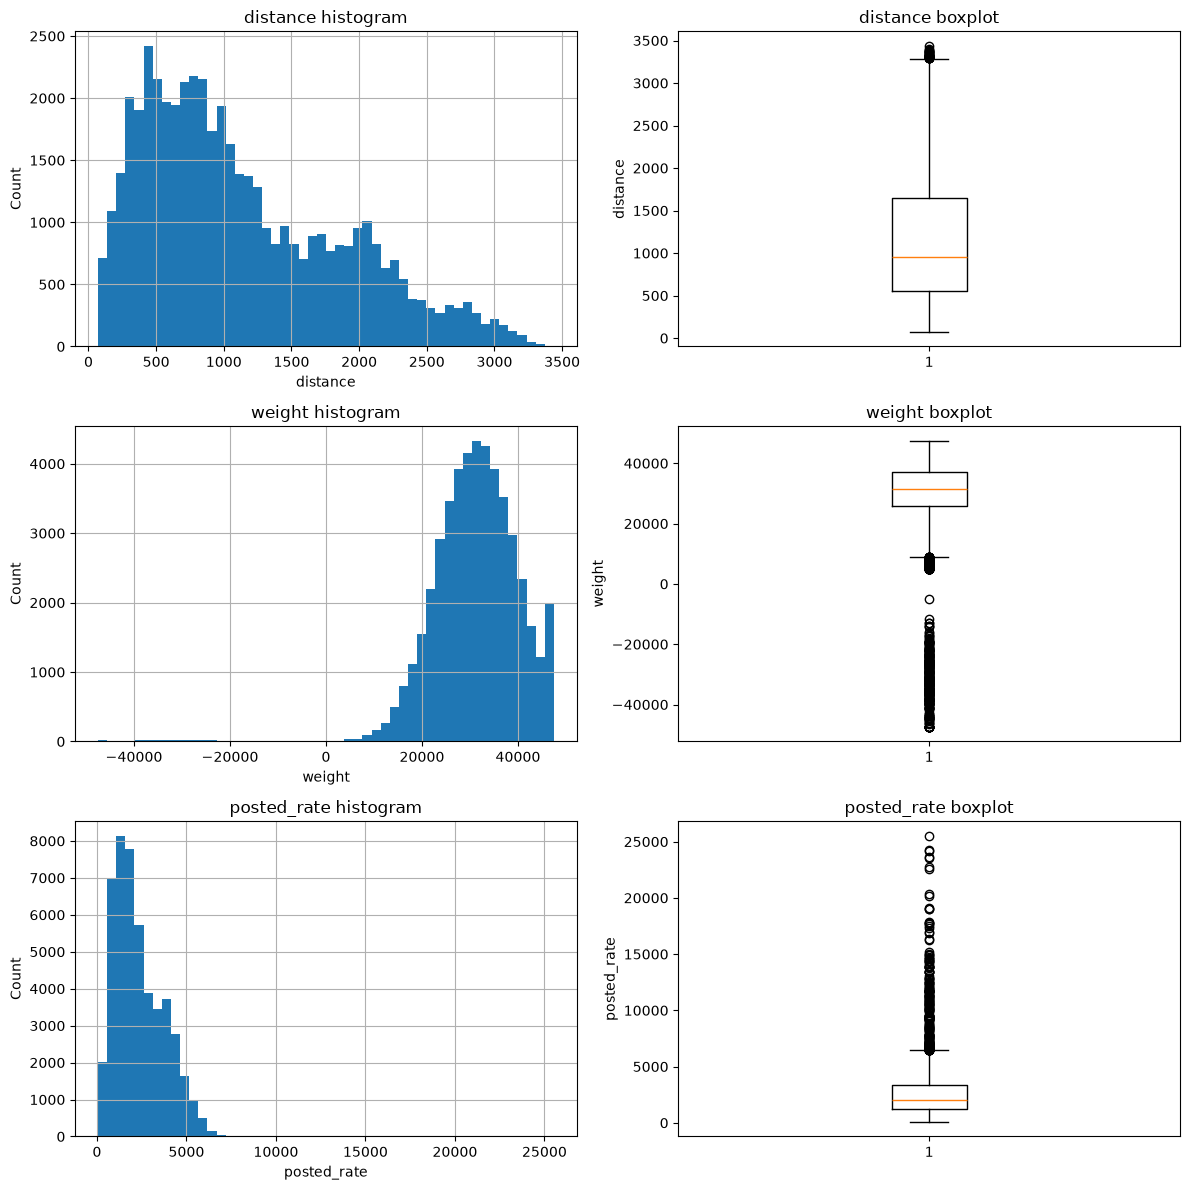

In [10]:
outlier_cols = ["distance", "weight", "posted_rate"]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row, column in enumerate(outlier_cols):
    df[column].hist(bins=50, ax=axes[row, 0])
    axes[row, 0].set_title(f"{column} histogram")
    axes[row, 0].set_xlabel(column)
    axes[row, 0].set_ylabel("Count")

    axes[row, 1].boxplot(df[column].dropna())
    axes[row, 1].set_title(f"{column} boxplot")
    axes[row, 1].set_ylabel(column)

plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

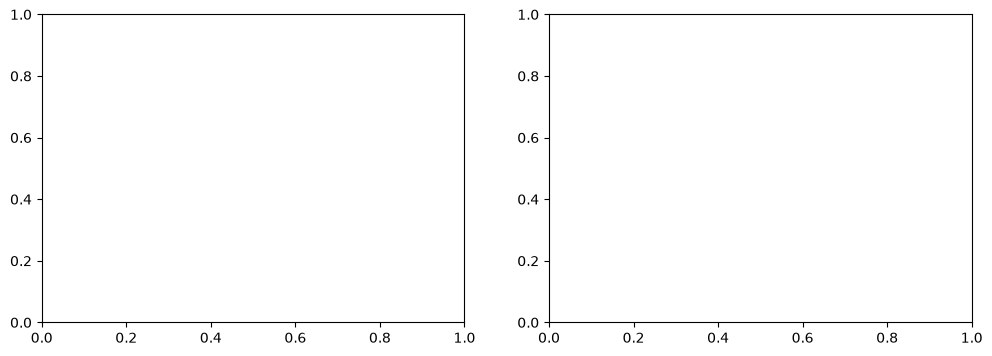

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["posted_rate"].hist(bins=50, ax=axes[0])
axes[0].set_title("Posted rate distribution")
axes[0].set_xlabel("Posted rate")
axes[0].set_ylabel("Count")

axes[1].boxplot(df["posted_rate"])
axes[1].set_title("Posted rate boxplot")
axes[1].set_ylabel("Posted rate")

plt.tight_layout()
plt.show()

In [4]:
negative_weight_rows = df[df["weight"] < 0]
nonpositive_distance_rows = df[df["distance"] <= 0]
nonpositive_rate_rows = df[df["posted_rate"] <= 0]
parsed_dates = pd.to_datetime(df["date"])

print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Duplicate rows:", df.duplicated().sum())
print("Negative weight rows:", len(negative_weight_rows))
print("Distance <= 0 rows:", len(nonpositive_distance_rows))
print("Posted rate <= 0 rows:", len(nonpositive_rate_rows))
print("Date parse failures:", parsed_dates.isna().sum())
print("Date range:", parsed_dates.min(), "to", parsed_dates.max())
print("Equipment categories:\n", df["equipment"].value_counts(dropna=False))

negative_weight_rows[["load_id", "weight"]].head()

NameError: name 'df' is not defined

In [23]:
eda_dates = pd.DatetimeIndex(sorted(df["date"].dropna().unique()))
eda_split_index = int(len(eda_dates) * 0.8)
eda_cutoff = eda_dates[eda_split_index]

eda_train = df[df["date"] < eda_cutoff].copy()
eda_valid = df[df["date"] >= eda_cutoff].copy()
official_validation_dates = pd.to_datetime(validation["date"])

print("Unique labeled dates:", len(eda_dates))
print("Cutoff date:", eda_cutoff)
print("Model-training rows:", len(eda_train), "| date range:", eda_train["date"].min(), "to", eda_train["date"].max())
print("Model-validation rows:", len(eda_valid), "| date range:", eda_valid["date"].min(), "to", eda_valid["date"].max())
print("Official validation date range:", official_validation_dates.min(), "to", official_validation_dates.max())
print("Official validation has posted_rate:", "posted_rate" in validation.columns)
print("Dates shared with official validation:", len(set(eda_dates).intersection(official_validation_dates)))

Unique labeled dates: 304
Cutoff date: 2025-09-01 00:00:00
Model-training rows: 38477 | date range: 2025-01-01 00:00:00 to 2025-08-31 00:00:00
Model-validation rows: 9523 | date range: 2025-09-01 00:00:00 to 2025-10-31 00:00:00
Official validation date range: 2025-11-01 00:00:00 to 2025-12-31 00:00:00
Official validation has posted_rate: False
Dates shared with official validation: 0


In [24]:
def add_freight_features(data):
    featured = data.copy()
    featured["date"] = pd.to_datetime(featured["date"])
    featured["month"] = featured["date"].dt.month
    featured["day_of_week"] = featured["date"].dt.dayofweek
    featured["week"] = featured["date"].dt.isocalendar().week.astype("int64")
    featured["quarter"] = featured["date"].dt.quarter
    featured["distance_squared"] = featured["distance"] ** 2
    featured["weight_per_mile"] = featured["weight"] / featured["distance"].where(featured["distance"] > 0)
    featured["lane"] = (
        featured["pickup"].fillna("__MISSING__").astype(str)
        + "_"
        + featured["delivery"].fillna("__MISSING__").astype(str)
    )
    for column in ["pickup", "delivery", "equipment"]:
        featured[column] = featured[column].fillna("__MISSING__").astype(str)
    return featured

train_features = add_freight_features(train)
validation_features = add_freight_features(validation)
df = train_features

categorical_features = ["pickup", "delivery", "equipment", "lane"]
cat_features = categorical_features.copy()

model_train = train_features[train_features["date"] < eda_cutoff].copy()
model_valid = train_features[train_features["date"] >= eda_cutoff].copy()

print("Train feature shape:", train_features.shape)
print("Validation feature shape:", validation_features.shape)
print("CatBoost categorical features:", cat_features)
train_features[["date", "month", "day_of_week", "week", "quarter", "distance_squared", "weight_per_mile", "lane"]].head()

Train feature shape: (48000, 21)
Validation feature shape: (12000, 20)
CatBoost categorical features: ['pickup', 'delivery', 'equipment', 'lane']


,date,month,day_of_week,week,quarter,distance_squared,weight_per_mile,lane
0,2025-01-01,1,2,1,1,75240.49,111.768137,Richmond_Baltimore
1,2025-01-01,1,2,1,1,78680.25,62.584670,Richmond_Philadelphia
2,2025-01-01,1,2,1,1,936636.84,32.776400,Philadelphia_Green Bay
3,2025-01-01,1,2,1,1,931997.16,33.491817,Hartford_Atlanta
4,2025-01-01,1,2,1,1,293655.61,64.925263,Dallas_Nashville


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

target_column = "posted_rate"
excluded_columns = ["load_id", "date", target_column]
feature_columns = [column for column in train_features.columns if column not in excluded_columns]
numeric_features = [column for column in feature_columns if column not in categorical_features]

one_hot_preprocessor = ColumnTransformer(
    transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)],
    remainder="passthrough",
    sparse_threshold=1.0,
)

X_train_ohe = one_hot_preprocessor.fit_transform(model_train[feature_columns])
X_valid_ohe = one_hot_preprocessor.transform(model_valid[feature_columns])
X_final_ohe = one_hot_preprocessor.transform(validation_features[feature_columns])
y_train = model_train[target_column]
y_valid = model_valid[target_column]

print("Numeric features passed through:", numeric_features)
print("One-hot training matrix shape:", X_train_ohe.shape)
print("One-hot holdout matrix shape:", X_valid_ohe.shape)
print("One-hot final-validation matrix shape:", X_final_ohe.shape)

Numeric features passed through: ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'month', 'day_of_week', 'week', 'quarter', 'distance_squared', 'weight_per_mile']
One-hot training matrix shape: (38477, 4144)
One-hot holdout matrix shape: (9523, 4144)
One-hot final-validation matrix shape: (12000, 4144)


In [10]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline

baseline_train_X = model_train[feature_columns].copy()
baseline_valid_X = model_valid[feature_columns].copy()

for features in [baseline_train_X, baseline_valid_X]:
    invalid_weight = features["weight"] < 0
    features.loc[invalid_weight, ["weight", "weight_per_mile"]] = np.nan

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    sparse_threshold=1.0,
)

linear_baseline = Pipeline(
    steps=[
        ("preprocessor", baseline_preprocessor),
        ("regressor", LinearRegression()),
    ]
)

linear_baseline.fit(baseline_train_X, y_train)
baseline_predictions = linear_baseline.predict(baseline_valid_X)
baseline_mae = mean_absolute_error(y_valid, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(y_valid, baseline_predictions))
baseline_mape = np.mean(np.abs((y_valid.to_numpy() - baseline_predictions) / y_valid.to_numpy())) * 100

print(f"Holdout MAE: ${baseline_mae:,.2f}")
print(f"Holdout RMSE: ${baseline_rmse:,.2f}")
print(f"Holdout MAPE: {baseline_mape:.2f}%")

Holdout MAE: $187.14
Holdout RMSE: $649.07
Holdout MAPE: 8.37%


In [26]:
from catboost import CatBoostRegressor

final_train_X = train_features[feature_columns].copy()
final_validation_X = validation_features[feature_columns].copy()

for features in [final_train_X, final_validation_X]:
    invalid_weight = features["weight"] < 0
    features.loc[invalid_weight, ["weight", "weight_per_mile"]] = np.nan

final_catboost_model = CatBoostRegressor(
    iterations=800,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)
final_catboost_model.fit(
    final_train_X,
    train_features[target_column],
    cat_features=categorical_features,
)

final_validation_predictions = validation[["load_id"]].copy()
final_validation_predictions["predicted_posted_rate"] = final_catboost_model.predict(final_validation_X)

print(f"Final CatBoost fitted on {len(final_train_X):,} labeled loads.")
print(f"Generated predictions for {len(final_validation_predictions):,} unlabeled validation loads.")
final_validation_predictions.head()

Final CatBoost fitted on 48,000 labeled loads.
Generated predictions for 12,000 unlabeled validation loads.


,load_id,predicted_posted_rate
0,TE-000001,900.121509
1,TE-000002,5188.485651
2,TE-000003,5495.365750
3,TE-000004,4111.672777
4,TE-000005,1797.987684


In [27]:
from pathlib import Path

submission_predictions = final_validation_predictions[["load_id"]].copy()
submission_predictions["predicted_rate"] = final_validation_predictions["predicted_posted_rate"]
assert submission_predictions.columns.tolist() == ["load_id", "predicted_rate"]
assert len(submission_predictions) == len(validation)

predictions_path = Path("..") / "validation_predictions.csv"
submission_predictions.to_csv(predictions_path, index=False)
print(f"Saved {len(submission_predictions):,} predictions to {predictions_path}.")

Saved 12,000 predictions to ..\validation_predictions.csv.
